# Photovoltaic Figure of Merit Code Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials

In [1]:
#import the required modules

import placeholder.db_fom as db_fom
import placeholder.pv_fom as pv_fom
import placeholder.db_plotting as db_plotting
import placeholder.final_results as final_results
import placeholder.vasp_inputs as vasp_inputs
import numpy as np # version - 1.26.4

## Using PV-FOM to generate VASP calculation files

### Geometry Optimisation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy position of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, materials project or experimental studies. The current code accepts VASP POSCAR/CONTCAR, .cif, .xyz or .json.
- Appropiate values for the ENCUT and KSPACING for your system. Convergence testing is the commonly used method of determining the appropiate values.
- The desired functional, it is recommended to use hybrid-DFT (HSE06 or PBE0) to achieve publishable results.

In [2]:
# Set the structure filename and calculation settings

filename = 'cdte/relaxed_primitive_POSCAR'
outdirectory = 'relax' # The folder you want to run the calculation in
functional = 'HSE06'            # The DFT functional
encut = 450                     
kspacing = 0.2

In [3]:

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=['relax_cell', 'tight_relax'], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

### Density of States 

This is required as a precursor to the optical absorption calculation that we need for much of the analysis. This time the structure we feed in is the CONTCAR from the Relaxation.

In [4]:
filename = 'relax/CONTCAR'
outdirectory = 'dos'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["dos"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

#### Analysing the Density of States


In [6]:
from sumo.cli.dosplot import dosplot

dosplot(filename='dos/vasprun.xml', xmin=-3, xmax=3, gaussian=0.05)

### Optical Calculations

This can be ran in the same folder as the density of states calculation - warning it will overwrite the previous DOS INCAR in order to do so.

In [7]:
filename = 'dos/POSCAR'
outdirectory = 'dos'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["optics"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

### Analysing the Optical Calculations

The initial step is using sumo to generate the required files, and plot the absorption onset.

In [8]:
# Generating the absorption.dat file and absorption onset plot, this will be saved as a PDF in the DOS folder

from sumo.cli.optplot import optplot

optplot(filenames='dos/vasprun.xml', directory='dos', xmax=5)

Followed by generating the SLME and Blank et.al metric.

In [20]:
# For the SLME and Blank et.al you need to run the optplot with nreal
# WARNING: it will overwrite the previous absorption spectra if you don't change the name of the file
from sumo.electronic_structure.optics import write_files
from pymatgen.io.vasp import Vasprun
import numpy as np

load_vasprun = Vasprun('dos/vasprun.xml')
dielectric = load_vasprun.dielectric

energies = np.array(dielectric[0])

real_eps = np.array(dielectric[1])[:, [[0, 3, 5], [3, 1, 4], [5, 4, 2]]]
imag_eps = np.array(dielectric[2])[:, [[0, 3, 5], [3, 1, 4], [5, 4, 2]]]
eps_full = real_eps + 1j * imag_eps

# take sqrt of eps matrix; if eps = V S V^-1; then eps^1/2 = V S^{1/2} V^-1;
eigvals, eigvecs = np.linalg.eig(eps_full)

# fancy einsum to calculate V S^{1/2} V^-1 at every energy
n = np.einsum("ijk,ik,ikl->ijl", eigvecs, np.sqrt(eigvals), np.linalg.inv(eigvecs))

# calculate optical absorption
alpha = n.imag * energies[:, None, None] * 4 * np.pi / 1.23984212e-4

# Invert epsilon to obtain energy-loss function
loss = -np.linalg.inv(eps_full).imag

eps = np.linalg.eigvals(eps_full).mean(axis=1)
n = np.linalg.eigvals(n).mean(axis=1)
loss = np.linalg.eigvalsh(loss).mean(axis=1)
alpha = np.linalg.eigvalsh(alpha).mean(axis=1)

data = {
    "eps_real": eps.real,
    "eps_imag": eps.imag,
    "n_real": n.real,
    "n_imag": n.imag,
    "loss": loss,
    "absorption": alpha,
}

print(data['n_real'])
#write_files(data, basename='n_real', prefix='dat', directory='dos')

[2.55487769 2.55489726 2.55491683 ... 0.91967386 0.91972822 0.91978258]


The Tauc Plots can then be generated

### Obtaining the Detailed Balance from Bandgap

Using the optical gaps taken from the Tauc Plots, the Detailed balance can be calculated. 

In [2]:
# Define the operating temperature of the cell, and bandgap from the Tauc plot

Tcell = 300
Egap = 1.45   # Using CdTe value

In [3]:
# Convert the spectrum

spectrum = db_fom.load_spectrum(spectrum_type="AM1.5")
photon_spectrum = db_fom.convert_spectrum(spectrum)


/root/miniconda3/envs/toolbox/lib/python3.9/site-packages/placeholder/db_plotting.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot([Egap], [p_above_1_1], 'ro', color='#FF6666')


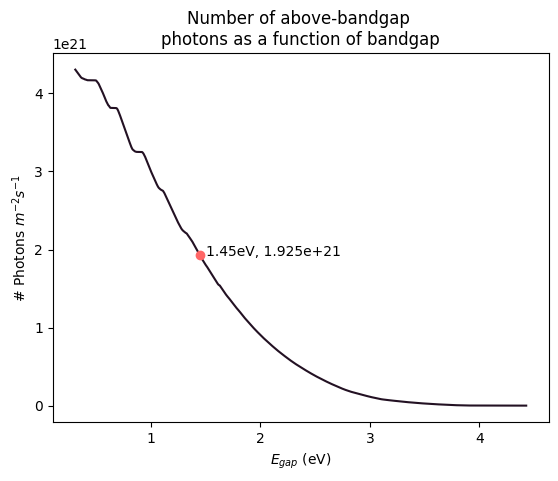

In [4]:
# Plot the phonons above bandgap

db_plotting.photons_above_bandgap_plot(photon_spectrum, Egap)

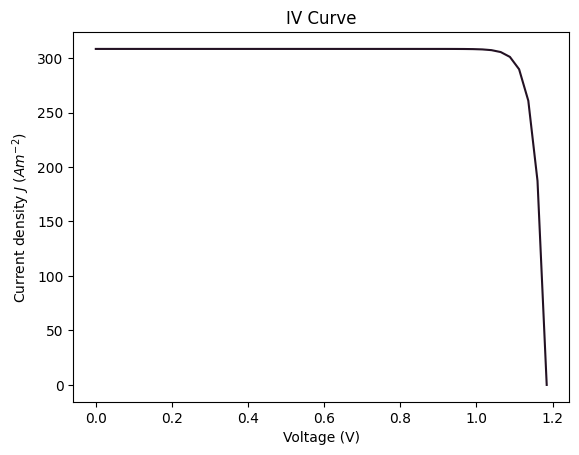

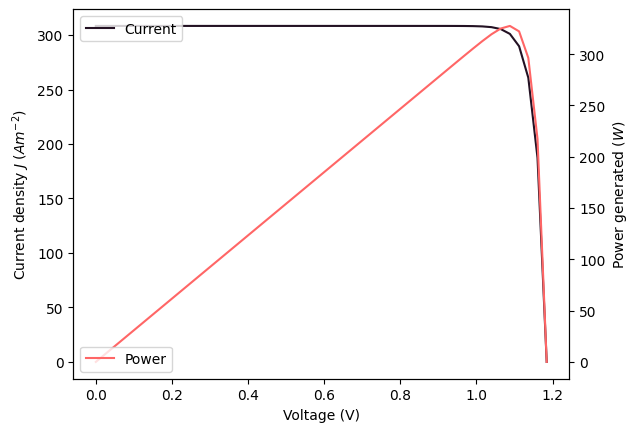

In [5]:
# IV Curve

db_plotting.iv_curve_plot(Egap, photon_spectrum, Tcell)
db_plotting.iv_curve_plot_2(Egap, photon_spectrum, Tcell)

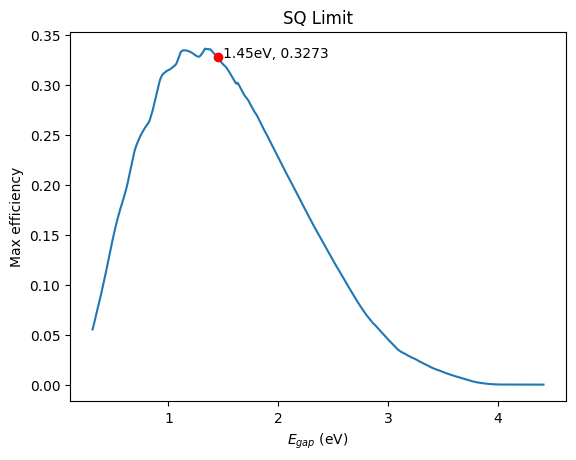

In [6]:
# The SQ limit plot

db_plotting.sq_limit_plot(photon_spectrum, Egap, Tcell)